*Assignment (11/03/2026)*
*Assignment Name* : Customer Segmentation
*Description* : Perform K-Means clustering on a mall dataset and describe customer groups.

Enter number of customers:  5



Customer 1


Enter Annual Income:  56
Enter Spending Score (1-100):  5



Customer 2


Enter Annual Income:  66
Enter Spending Score (1-100):  4


...

Enter Annual Income:  45
Enter Spending Score (1-100):  6



Customer Dataset:
   Income  SpendingScore
0      56              5
1      66              4
2      78              6
3      55              4
4      45              6



Enter number of clusters:  2


C:\Users\rohit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Clustered Data:
   Income  SpendingScore  Cluster
0      56              5        1
1      66              4        0
2      78              6        0
3      55              4        1
4      45              6        1


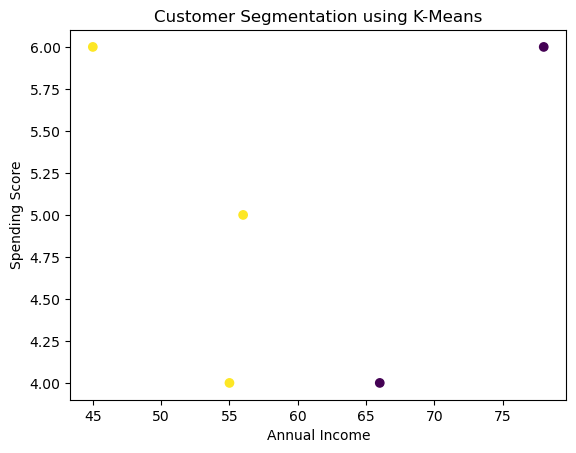


Customer Group 0
   Income  SpendingScore  Cluster
1      66              4        0
2      78              6        0

Customer Group 1
   Income  SpendingScore  Cluster
0      56              5        1
3      55              4        1
4      45              6        1


In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Number of customers
n = int(input("Enter number of customers: "))

income = []
spending = []

# Take customer data
for i in range(n):
    print("\nCustomer", i+1)
    inc = int(input("Enter Annual Income: "))
    spend = int(input("Enter Spending Score (1-100): "))
    
    income.append(inc)
    spending.append(spend)

# Create dataset
data = pd.DataFrame({
    "Income": income,
    "SpendingScore": spending
})

print("\nCustomer Dataset:")
print(data)

# Number of clusters
k = int(input("\nEnter number of clusters: "))

# Ensure clusters are not greater than customers
if k > n:
    print("\nClusters cannot be greater than number of customers.")
    k = n
    print("Clusters set to:", k)

# Apply K-Means
model = KMeans(n_clusters=k, n_init=10, random_state=0)
data["Cluster"] = model.fit_predict(data)

print("\nClustered Data:")
print(data)

# Plot clusters
plt.scatter(data["Income"], data["SpendingScore"], c=data["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")
plt.show()

# Display customer groups
for i in range(k):
    print("\nCustomer Group", i)
    print(data[data["Cluster"] == i])